# Регрессия, классификация и  кластеризация
# Введение в Scikit-Learn

Существует несколько библиотек Python, которые обеспечивают надежную реализацию ряда алгоритмов машинного обучения.
Одним из самых известных является [Scikit-Learn](http://scikit-learn.org), пакет, предоставляющий эффективные версии большого количества распространенных алгоритмов. Scikit-Learn характеризуется чистым, унифицированным и оптимизированным API, а также очень полезной и полной онлайн-документацией.
Преимущество такого единообразия заключается в том, что как только вы поймете основное использование и синтаксис Scikit-Learn для одного типа модели, переход на новую модель или алгоритм будет очень простым.


## Представление данных в Scikit-Learn

Машинное обучение — это создание моделей из данных: по этой причине мы начнем с обсуждения того, как данные могут быть представлены, чтобы их мог понять компьютер.

### Данные в виде таблицы

Базовая таблица представляет собой двумерную сетку данных, в которой строки представляют отдельные элементы набора данных, а столбцы представляют количества, относящиеся к каждому из этих элементов.
Например, рассмотрим [набор данных Iris](https://en.wikipedia.org/wiki/Iris_flower_data_set), тщательно проанализирован Рональдом Фишером в 1936 году.
Мы можем загрузить этот набор данных в виде ``DataFrame`` Pandas, используя
[seaborn](http://seaborn.pydata.org/) library:

In [6]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head(-5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
140,6.7,3.1,5.6,2.4,virginica
141,6.9,3.1,5.1,2.3,virginica
142,5.8,2.7,5.1,1.9,virginica
143,6.8,3.2,5.9,2.3,virginica


Здесь каждая строка данных относится к одному наблюдаемому цветку, а количество строк — это общее количество цветов в наборе данных.
В общем, мы будем называть строки матрицы *выборками*, а количество строк - ``n_samples``.

Точно так же каждый столбец данных относится к определенной количественной информации, описывающей каждый образец.
В общем, мы будем называть столбцы матрицы *признаками*, а количество столбцов — ``n_features``.

#### Матрица характеристик

Этот макет таблицы ясно показывает, что информацию можно рассматривать как двумерный числовой массив или матрицу, которую мы будем называть *матрицей признаков*.
По соглашению эта матрица характеристик часто хранится в переменной с именем ``X``.
Предполагается, что матрица функций является двумерной, имеет форму ``[n_samples, n_features]`` и чаще всего содержится в массиве NumPy или в Pandas ``DataFrame``, хотя некоторые модели Scikit-Learn также принимают SciPy. разреженные матрицы.

Образцы (т. е. строки) всегда относятся к отдельным объектам, описанным в наборе данных.
Например, образцом может быть цветок, человек, документ, изображение, звуковой файл, видео, астрономический объект или что-то еще, что вы можете описать набором количественных измерений.

Признаки (т. е. столбцы) всегда относятся к отдельным наблюдениям, которые количественно описывают каждую выборку.
Функции, как правило, имеют действительные значения, но в некоторых случаях могут быть булевыми или дискретными.

#### Целевой массив

В дополнение к матрице признаков ``X``, мы также обычно работаем с массивом *label* или *target*, который по соглашению мы обычно будем называть ``y``.
Целевой массив обычно одномерный, с длиной ``n_samples`` и обычно содержится в массиве NumPy или Pandas Series.
Целевой массив может иметь непрерывные числовые значения или дискретные классы/метки.
В то время как некоторые оценщики Scikit-Learn обрабатывают несколько целевых значений в форме двумерного целевого массива ``[n_samples, n_targets]``, мы в основном будем работать с распространенным случаем одномерного целевого массива.

Часто путаница заключается в том, чем целевой массив отличается от других столбцов функций. Отличительной чертой целевого массива является то, что обычно это значения, которое мы хотим *предсказать на основе данных*: в статистических терминах это зависимая переменная.
Например, на основе предыдущих данных мы можем построить модель, которая может предсказать вид цветка на основе других измерений; в этом случае столбец «species» будет считаться целевым массивом.

Помня об этом целевом массиве, мы можем использовать Seaborn для удобной визуализации данных:

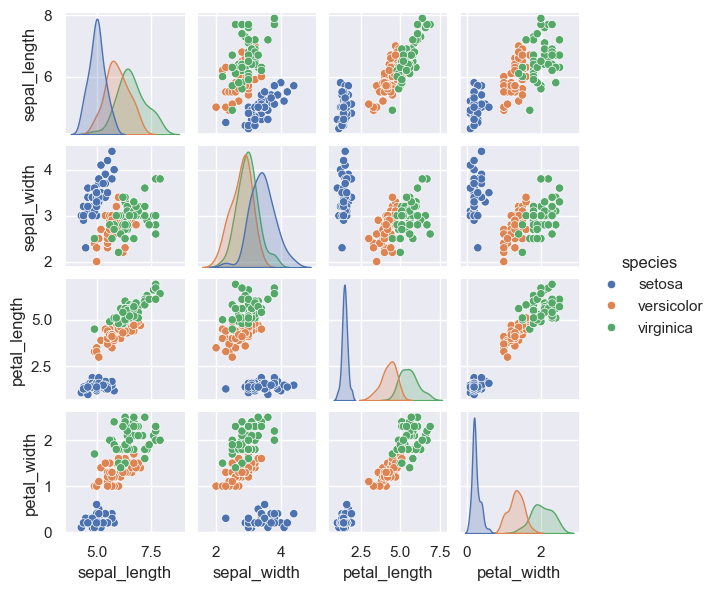

In [2]:
%matplotlib inline
import seaborn as sns; sns.set()
sns.pairplot(iris, hue='species', height=1.5);

Для использования в Scikit-Learn мы извлечем матрицу функций и целевой массив из ``DataFrame``, что мы можем сделать, используя некоторые операции Pandas ``DataFrame``

In [3]:
X_iris = iris.drop('species', axis=1)
X_iris.shape

(150, 4)

In [4]:
y_iris = iris['species']
y_iris.shape

(150,)

Подводя итог, ожидаемое расположение функций и целевых значений визуализируется на следующей диаграмме:

![](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/figures/05.02-samples-features.png?raw=1)

Правильно отформатировав эти данные, мы можем перейти к рассмотрению *estimator* API Scikit-Learn:

## API оценки Scikit-Learn

Scikit-Learn API разработан с учетом следующих руководящих принципов, изложенных в [документе Scikit-Learn API](http://arxiv.org/abs/1309.0238):

- *Согласованность*: Все объекты имеют общий интерфейс, основанный на ограниченном наборе методов, с согласованной документацией.

- *Проверка*: все указанные значения параметров выставляются как общедоступные атрибуты.

- *Ограниченная иерархия объектов*: классы Python представляют только алгоритмы; наборы данных представлены в стандартных форматах (массивы NumPy, DataFrame Pandas, разреженные матрицы SciPy), а имена параметров используют стандартные строки Python.

- *Композиция*: Многие задачи машинного обучения могут быть выражены в виде последовательностей более фундаментальных алгоритмов, и Scikit-Learn использует это везде, где это возможно.

- *Разумные значения по умолчанию*: Когда модели требуют пользовательских параметров, библиотека определяет соответствующее значение по умолчанию.

На практике эти принципы делают Scikit-Learn очень простым в использовании, если понять основные принципы.
Каждый алгоритм машинного обучения в Scikit-Learn реализуется через Estimator API, который обеспечивает согласованный интерфейс для широкого спектра приложений машинного обучения.

### Основы API

Чаще всего шаги по использованию API оценки Scikit-Learn следующие:
(мы рассмотрим несколько подробных примеров в следующих разделах).

1. Выберите класс модели, импортировав соответствующий класс оценщика из Scikit-Learn.
2. Выберите гиперпараметры модели, создав экземпляр этого класса с желаемыми значениями.
3. Расположите данные в матрице признаков и целевом векторе, следуя приведенному выше обсуждению.
4. Сопоставьте модель с вашими данными, вызвав метод ``fit()`` экземпляра модели.
5. Примените модель к новым данным:
   - При обучении с учителем часто предсказываются метки для неизвестных данных, используя метод predict().
   - Для неконтролируемого обучения часто преобразуются или выводятся свойства данных, используя метод «transform()» или «predict()».

Далее рассмотрим несколько простых примеров применения контролируемых и неконтролируемых методов обучения.

### Пример контролируемого обучения: простая линейная регрессия

В качестве примера этого процесса рассмотрим простую линейную регрессию, то есть обычный случай подгонки линии к данным $(x, y)$.
Мы будем использовать следующие простые данные для нашего примера регрессии:

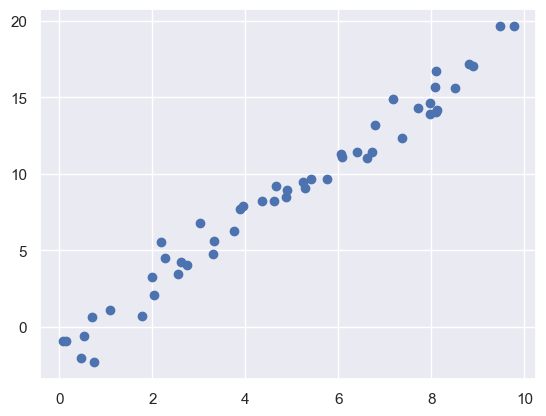

In [5]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.RandomState(442)
x = 10 * rng.rand(50)
y = 2 * x - 1 + rng.randn(50)
plt.scatter(x, y);

Имея эти данные, мы можем использовать описанный ранее подход. Пройдемся по процессу:

#### 1. Выбор класса модели

В Scikit-Learn каждый класс модели представлен классом Python.
Так, например, если мы хотим вычислить простую модель линейной регрессии, мы можем импортировать класс линейной регрессии:

In [10]:
from sklearn.linear_model import LinearRegression

Обратите внимание, что существуют и другие более общие модели линейной регрессии; вы можете прочитать больше о них в документации модуля [``sklearn.linear_model``](http://Scikit-Learn.org/stable/modules/linear_model.html).

#### 2. Выбор гиперпараметров модели

Важным моментом является то, что *класс модели — это не то же самое, что экземпляр модели*.

После того, как мы определились с классом нашей модели, у нас еще есть несколько вариантов.
В зависимости от класса модели, с которым мы работаем, нам может потребоваться ответить на один или несколько вопросов, например:

- Хотели бы мы учитвать пересечение с осью ординат (по *y-intercept*)?
- Хотели бы мы, чтобы модель была нормализована?
- Хотели бы мы предварительно обработать наши функции, чтобы добавить гибкости модели?
- Какую степень регуляризации мы хотели бы использовать в нашей модели?
- Сколько компонентов модели мы хотели бы использовать?

Эти важные пункты необходимо проанализировать *после выбора класса модели*.
Эти пункты в калассах часто представлены в виде *гиперпараметров* или параметров, которые должны быть установлены до того, как модель будет обучена.
В Scikit-Learn гиперпараметры выбираются путем передачи значений при создании экземпляра модели.

For our linear regression example, we can instantiate the ``LinearRegression`` class and specify that we would like to fit the intercept using the ``fit_intercept`` hyperparameter:
Для нашего примера линейной регрессии мы можем создать экземпляр класса ``LinearRegression`` и указать, что мы хотели бы подогнать точку пересечения, используя гиперпараметр ``fit_intercept``:

In [26]:
model = LinearRegression(fit_intercept=True)
model

LinearRegression()

#### 3. Расположение данных в матрице признаков и целевом векторе

Ранее мы подробно описали представление данных Scikit-Learn, для которого требуется двумерная матрица признаков и одномерный целевой массив.
Здесь наша целевая переменная `y` уже имеет правильную форму (массив `length-n_samples`), но нам нужно обработать данные `x`, чтобы сделать их матрицей размера ``[n_samples , n_features]``.
В данном случае это сводится к простому изменению формы одномерного массива:

In [7]:
X = x[:, np.newaxis]
X.shape

(50, 1)

#### 4. Подгонка (обучение) модели к данным

Теперь пришло время применить нашу модель к данным.
Это можно сделать с помощью метода модели fit():

In [28]:
model.fit(X, y)

LinearRegression()

Команда ``fit()`` вызывает ряд внутренних вычислений, зависящих от модели, и результаты этих вычислений сохраняются в атрибутах, специфичных для модели, которые пользователь может исследовать.
В Scikit-Learn по соглашению все параметры модели, которые были изучены в процессе ``fit()``, заканчиваются символами подчеркивания; например, в этой линейной модели мы имеем следующее:

In [29]:
model.coef_

array([2.06953161])

In [30]:
model.intercept_

-1.4096790117198505

Эти два параметра представляют наклон и точку пересечения простой линейной подгонки к данным.
По сравнению с определением данных мы видим, что они очень близки к входному наклону 2 и пересечению -1.

Один из часто возникающих вопросов касается неопределенности таких внутренних параметров модели.
В общем, Scikit-Learn не предоставляет инструментов для того, чтобы делать выводы из самих внутренних параметров модели: интерпретация параметров модели — это скорее вопрос *статистического моделирования*, чем вопрос *машинного обучения*.
Машинное обучение скорее фокусируется на том, что модель *предсказывает*.
Если вы хотите углубиться в значение параметров подгонки в модели, доступны другие инструменты, в том числе [Пакет Statsmodels Python](http://statsmodels.sourceforge.net/).

#### 5. Прогнозирование для неизвестных данных

После того, как модель обучена, основная задача машинного обучения с учителем — оценить ее на основе того, что она говорит о новых данных, которые не были частью обучающей выборки.
В Scikit-Learn это можно сделать с помощью метода predict().
Для этого примера наши «новые данные» будут представлять собой сетку значений *x*, и спрогнозируем ​​какие значения *y* предсказывает модель:

In [31]:
xfit = np.linspace(-1, 11)

Как и раньше, нам нужно преобразовать эти значения *x* в матрицу признаков ``[n_samples, n_features]``, после чего мы можем передать их модели:

In [32]:
Xfit = xfit[:, np.newaxis]
yfit = model.predict(Xfit)

Наконец, давайте визуализируем результаты, построив сначала необработанные данные, а затем подобрав эту модель:

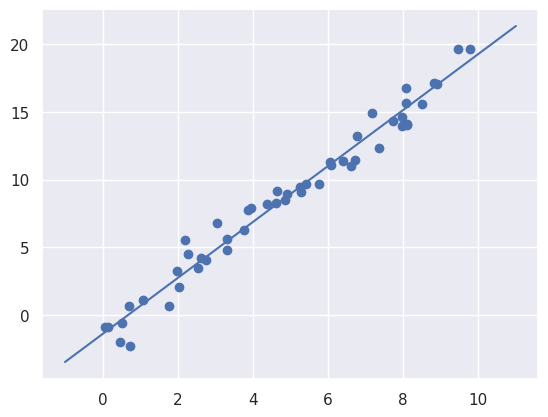

In [33]:
plt.scatter(x, y)
plt.plot(xfit, yfit);

Обычно эффективность модели оценивается путем сравнения ее результатов с некоторым известным исходным уровнем, как мы увидим в следующем примере.

### Пример контролируемого обучения: классификация ирисов

Давайте посмотрим на другой пример этого процесса, используя набор данных Iris, который мы обсуждали ранее.
Наш вопрос будет таким: учитывая модель, обученную на части данных Iris, насколько хорошо мы можем предсказать оставшиеся метки?

Для этой задачи мы будем использовать чрезвычайно простую генеративную модель, известную как гауссовская наивная байесовская модель, которая исходит из предположения, что каждый класс получен из гауссовского распределения, выровненного по осям.
Поскольку он очень быстрый и не имеет гиперпараметров для выбора, гауссовская наивная байесовская модель часто является хорошей моделью для использования в качестве базовой классификации, прежде чем исследовать, можно ли найти улучшения с помощью более сложных моделей.

Мы хотели бы оценить модель на данных, которых она раньше не видела, поэтому мы разделим данные на *тренировочный набор* и *тестовый набор*.
Это можно сделать вручную, но удобнее использовать служебную функцию ``train_test_split``:

In [11]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X_iris, y_iris,
                                                test_size=0.15,
                                                random_state=1)

Упорядочив данные, приступаем к обучению и классификации:

In [12]:
from sklearn.naive_bayes import GaussianNB # 1. Выбираем класс модели
model = GaussianNB()                       # 2. Инициализируем модель
model.fit(Xtrain, ytrain)                  # 3. Обучаем модель
y_model = model.predict(Xtest)             # 4. Выполняем классификацию

Наконец, мы можем использовать утилиту «accuracy_score», чтобы увидеть долю предсказанных меток, которые соответствуют их истинному значению:

In [13]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest, y_model)

0.9565217391304348

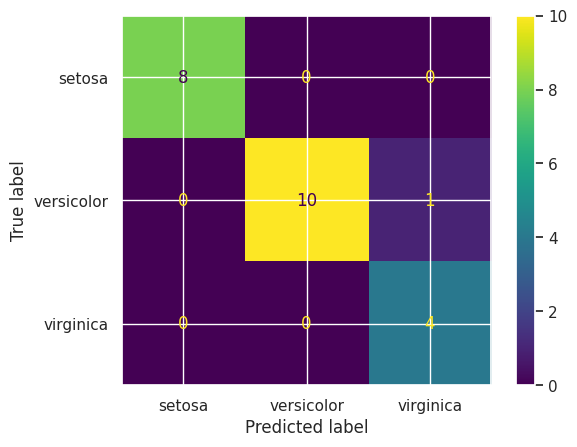

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# cm = confusion_matrix(ytest[y_model=='virginica'], y_model[y_model=='virginica'])
cm = confusion_matrix(ytest, y_model)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['setosa','versicolor','virginica'])
disp.plot()
plt.show()

# print(y_model[y_model=='setosa'])
# print(ytest[y_model=='setosa'])

С точностью выше 95% определено, что даже этот очень наивный алгоритм классификации эффективен для этого конкретного набора данных.

### Неконтролируемое обучение: кластеризация

Давайте теперь рассмотрим применение кластеризации к данным Iris.
Алгоритм кластеризации пытается найти отдельные группы данных без ссылки на какие-либо метки.
Здесь мы будем использовать мощный метод кластеризации, называемый смешанной моделью Гаусса (GMM).
GMM пытается смоделировать данные как набор гауссовских пятен.

Мы можем обучить GMM модель следующим образом:

In [ ]:
from sklearn.mixture import GaussianMixture as GMM      # 1. Выбор класса
model = GMM(n_components=3,
            covariance_type='full')  # 2. Ввод гиперпараметров
model.fit(X_iris)                    # 3. Обучение модели
y_gmm = model.predict(X_iris)        # 4. Определяем метки кластеров

Как и прежде, добавим метку кластера в Iris ``DataFrame`` и воспользуемся Seaborn для построения результатов:

Оригинальный дата сет


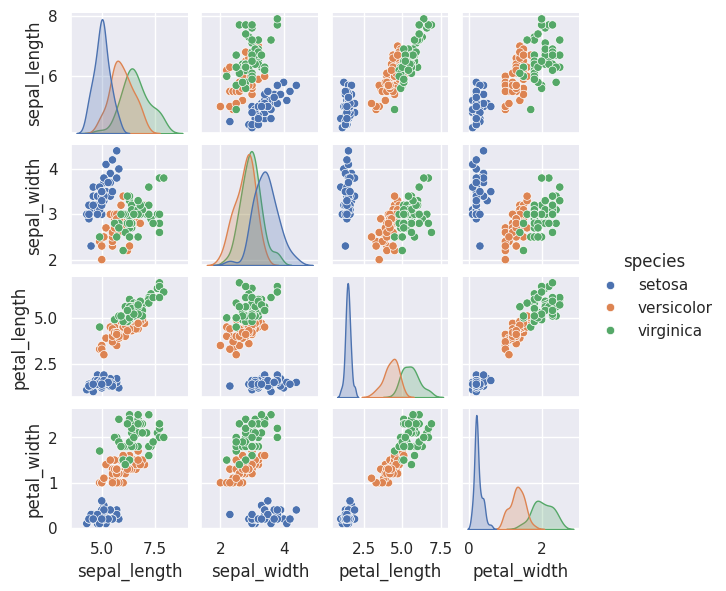

Спрогнозированный дата сет


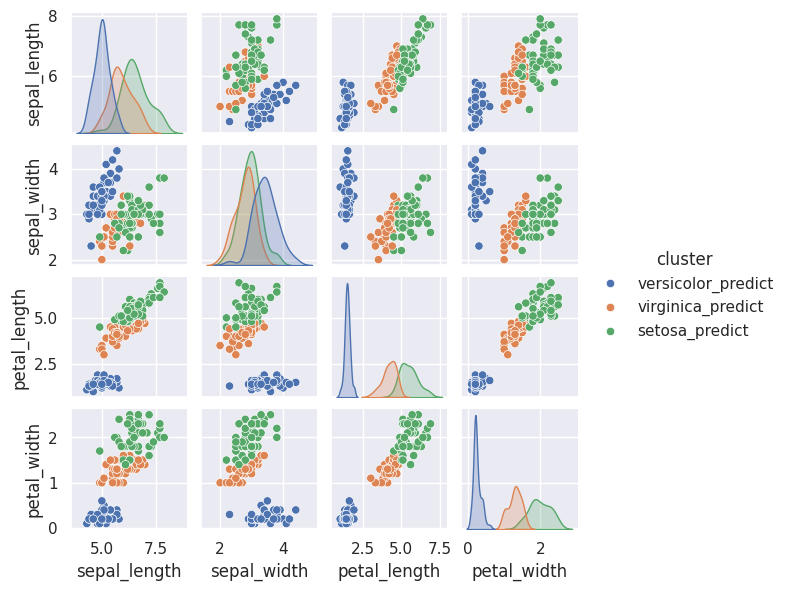

In [ ]:
print('Оригинальный дата сет')
sns.pairplot(iris, hue='species', height=1.5);
plt.show()

iris['cluster'] = y_gmm
iris['cluster'] = iris['cluster'].replace(0, 'setosa_predict')
iris['cluster'] = iris['cluster'].replace(1, 'versicolor_predict')
iris['cluster'] = iris['cluster'].replace(2, 'virginica_predict')

print('Спрогнозированный дата сет')
sns.pairplot(iris, hue='cluster', height=1.5);
plt.show()

Разделив данные по номеру кластера, мы видим, насколько хорошо алгоритм GMM восстановил базовую метку: виды *setosa* идеально разделены в пределах кластера 0, в то время как между *versicolor* и *virginica* остается небольшое смешивание.
Это означает, что даже без учителя, который сообщил бы нам видовые метки отдельных цветов, размеры этих цветов достаточно различны, чтобы мы могли *автоматически* идентифицировать присутствие этих различных групп видов с помощью простого алгоритма кластеризации!

## Лабораторное задание

1. Изучить ноутбук;

2. Произвести классификацию породы пингвинов ( дата сет  sns.load_dataset('penguins'));

3. Изучить влияние признаков на конечную точность классификации породы пингвина. Выполнить классификацию породы пингвина при изменении количества признаков от 2 до 6;

4. Составить [матрицу несоответствия](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).